# Importing the necessary libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Dataset
Data of 100 Students (Hours Studied vs Exam Scores)

In [ ]:
# Hours Studied
hours = np.array([
    0.5, 0.8, 1.1, 1.4, 1.6, 1.9, 2.1, 2.3, 2.5, 2.8,
    3.0, 3.2, 3.5, 3.7, 3.9, 4.1, 4.3, 4.5, 4.8, 5.0,
    5.2, 5.4, 5.6, 5.8, 6.0, 6.2, 6.5, 6.7, 6.9, 7.1,
    7.3, 7.5, 7.8, 8.0, 8.2, 8.4, 8.6, 8.9, 9.1, 9.3,
    9.5, 9.7, 0.6, 1.3, 2.2, 3.4, 4.6, 5.7, 6.8, 7.9,
    8.8, 9.9, 0.9, 1.8, 2.7, 3.6, 4.9, 5.9, 6.6, 7.4,
    8.3, 9.2, 0.7, 1.5, 2.4, 3.3, 4.2, 5.3, 6.4, 7.2,
    8.5, 9.6, 0.4, 1.7, 2.6, 3.8, 4.7, 5.5, 6.3, 7.7,
    8.7, 9.8, 0.3, 1.2, 2.9, 3.1, 4.4, 5.1, 6.1, 7.0,
    8.1, 9.4, 2.0, 4.0, 6.0, 8.0, 3.5, 5.5, 7.5, 9.5
]).reshape(-1, 1)

# Exam Scores
scores = np.array([
    38, 42, 45, 48, 50, 53, 55, 58, 60, 63,
    65, 67, 70, 72, 74, 76, 78, 80, 83, 85,
    87, 89, 91, 93, 95, 97, 98, 99, 99, 100,
    99, 98, 97, 95, 93, 91, 89, 87, 85, 83,
    81, 79, 39, 47, 56, 69, 79, 88, 96, 94,
    86, 78, 43, 52, 61, 71, 82, 90, 95, 92,
    84, 82, 41, 49, 58, 68, 77, 85, 93, 91,
    83, 77, 37, 51, 60, 73, 81, 87, 92, 90,
    85, 76, 36, 46, 64, 66, 79, 84, 91, 93,
    82, 75, 54, 75, 91, 94, 70, 87, 92, 74
])

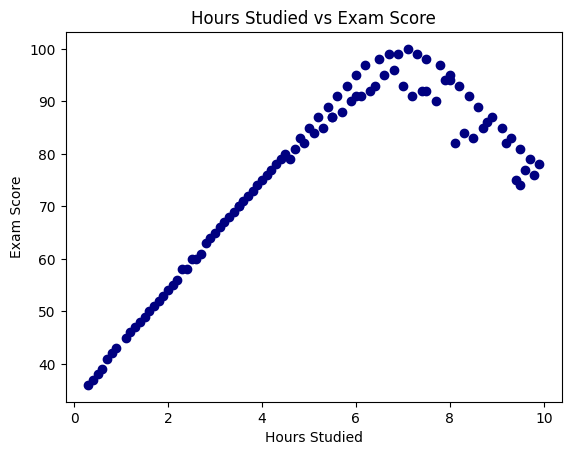

In [ ]:
# Visualize the data
plt.scatter(hours, scores, color='navy')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Hours Studied vs Exam Score')
plt.show()

# The Train-Test split
Split the data into Train and Test sets.
E.g.: test_size = 0.25, i.e., 25% Test data and 75% Train data

In [ ]:
# Split: 75% Train, 25% Test
X_train, X_test, y_train, y_test = train_test_split(hours,
                                                    scores,
                                                    test_size=0.25,
                                                    random_state=42)

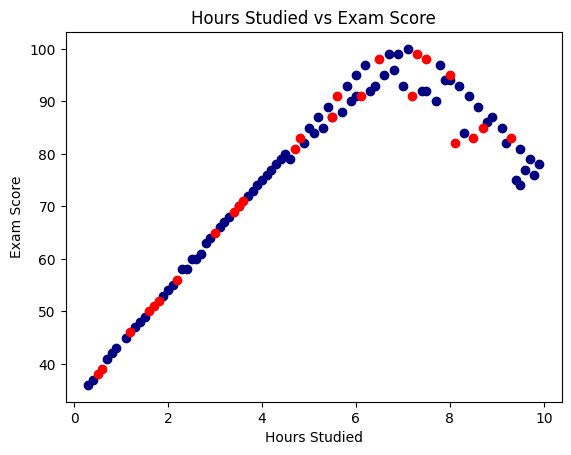

In [ ]:
# Visualize the data with train data with same blue color and test data with red color
plt.scatter(X_train, y_train, color='navy', label='Train Data')
plt.scatter(X_test, y_test, color='red', label='Test Data')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Hours Studied vs Exam Score')
plt.show()

# Feature Transformation
Transform the input features with a specific degree of polynomial

E.g.: 2, 3...
Consider '2' for this example

In [ ]:
def polynomial_features(X, degree):
    """
    Builds polynomial expansion:
    degree=2  -> [1, x, x^2]
    degree=3  -> [1, x, x^2, x^3]
    """
    X_poly = np.hstack([X**d for d in range(1, degree+1)])
    return np.column_stack((np.ones(X.shape[0]), X_poly))

degree = 2

X_train_poly = polynomial_features(X_train, degree)
X_test_poly  = polynomial_features(X_test,  degree)

# Normal Equation (Or, Model Training)
Calculate the weight vector 'w' or 'θ'

by solving the normal equation

((X^T X)^(-1)) * θ = (X^T y)

θ = ((X^T X)^(-1)) . (X^T y)



In [ ]:
X_T_X = X_train_poly.T @ X_train_poly
X_T_X_Inv = np.linalg.inv(X_T_X)
X_T_y = X_train_poly.T @ y_train

# Solve Normal Equation
theta = np.dot(X_T_X_Inv, X_T_y)

In [ ]:
print("Learned Parameters:")
for i, w in enumerate(theta.flatten()):
    print(f"w{i} = {w:.4f}")

Learned Parameters:
w0 = 23.0149
w1 = 19.3202
w2 = -1.3749


# Prediction & Visualization

In [ ]:
# Predictions
train_predictions = X_train_poly @ theta
test_predictions = X_test_poly @ theta

In [ ]:
# Calculate RMSE
train_rmse = np.sqrt(np.mean((y_train - train_predictions)**2))
test_rmse = np.sqrt(np.mean((y_test - test_predictions)**2))

print(f"Training RMSE: {train_rmse:.2f}")
print(f"Test Set RMSE: {test_rmse:.2f}")

Training RMSE: 3.90
Test Set RMSE: 4.17


Visualizing Regression line

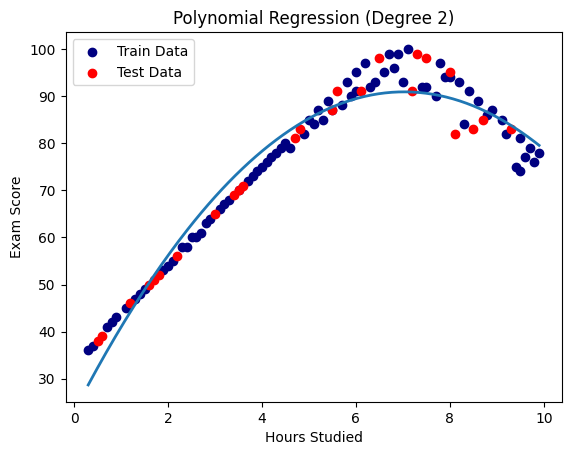

In [ ]:
# Plot the regression line
plt.scatter(X_train, y_train, color='navy', label='Train Data')
plt.scatter(X_test, y_test, color='red', label='Test Data')

# Regression curve
x_curve = np.linspace(hours.min(), hours.max(), 200).reshape(-1, 1)
X_curve_poly = polynomial_features(x_curve, degree)
y_curve = X_curve_poly @ theta

plt.plot(x_curve, y_curve, linewidth=2)

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Polynomial Regression (Degree 2)")
plt.legend()
plt.show()

#Scikit-learn Version

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=2)

model = LinearRegression()
model.fit(poly.fit_transform(X_train), y_train)

print("Learned Parameters:")
print(f"w0 = {model.intercept_:.4f}")
for i, w in enumerate(model.coef_[1:],1):
    print(f"w{i} = {w:.4f}")


Learned Parameters:
w0 = 23.0149
w1 = 19.3202
w2 = -1.3749


# Summary and Comparison

Model parameters from implementing using Math from scratch.

w0 = 23.0149
w1 = 19.3202
w2 = -1.3749

Model parameters from implemeting using Scikit-learn

w0 = 23.0149
w1 = 19.3202
w2 = -1.3749

Both implementations produce same parameters.

# Overfitting
Increasing the degree of polynomial, will result in overfitting

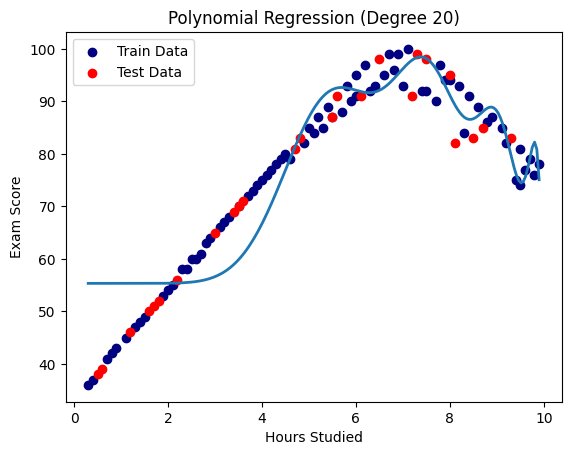

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=20)

model = LinearRegression()
model.fit(poly.fit_transform(X_train), y_train)

# Plot the regression line
plt.scatter(X_train, y_train, color='navy', label='Train Data')
plt.scatter(X_test, y_test, color='red', label='Test Data')

# Regression curve
x_curve = np.linspace(hours.min(), hours.max(), 200).reshape(-1, 1)
X_curve_poly = poly.fit_transform(x_curve)
y_curve = model.predict(X_curve_poly)

plt.plot(x_curve, y_curve, linewidth=2)

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Polynomial Regression (Degree 20)")
plt.legend()
plt.show()